# Generative AI use among CU Boulder graduate respondents

This notebook separates data setup from presentation plotting so that every figure uses the
same validated analytical bases. It retains partial completions when the relevant AI item is
valid, reports item-specific denominators, and treats institutional fields conservatively.

**Scope note.** The supplied file describes survey respondents. It does not include survey
weights, a population frame, gender, or race, so it cannot establish population
representativeness or quantify survey response bias. The composition and item-response tables
below identify potential limitations within the supplied respondent file.

In [1]:
# Imports and one global Matplotlib theme.
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)


# Matplot Global Styling
plt.rcParams.update(
    {
        "figure.facecolor": "#E6E0D9",
        "axes.facecolor": "#E6E0D9",
        "savefig.facecolor": "#E6E0D9",
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.titlelocation": "center",
        "axes.labelsize": 12,
        "axes.labelweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "#3E3E3E",
        "axes.linewidth": 0.9,
        "axes.axisbelow": True,
        "axes.grid": True,
        "grid.color": "#A7A7A7",
        "grid.linestyle": (0, (3, 3)),
        "grid.linewidth": 0.7,
        "grid.alpha": 0.38,
        "xtick.color": "#3E3E3E",
        "ytick.color": "#3E3E3E",
        "text.color": "#3E3E3E",
        "axes.labelcolor": "#3E3E3E",
        "legend.frameon": False,
        "figure.dpi": 110,
        "savefig.dpi": 220,
        "savefig.bbox": "tight",
    }
)


# Title centering, bold and subtitle conditional sub-function
def add_title(ax, title, subtitle=None, pad=24):
    ax.set_title(title, loc="center", fontweight="bold", pad=pad)
    if subtitle:
        ax.text(
            0.5,
            1.01,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=10.5,
            color="#6F6F6F",
        )


# Legend below x axis sub-function
def legend_below(ax, handles=None, labels=None, ncol=None, y=-0.25):
    if handles is None or labels is None:
        handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, y),
            ncol=ncol or len(handles),
            columnspacing=1.4,
            handlelength=1.2,
        )


# Summary stats table formatting
def style_table(frame, caption, formats=None):
    try:
        return (
            frame.style.hide(axis="index")
            .format(formats or {}, na_rep="—")
            .set_caption(caption)
            .set_table_styles(
                [
                    {
                        "selector": "caption",
                        "props": [
                            ("caption-side", "top"),
                            ("font-size", "15px"),
                            ("font-weight", "bold"),
                            ("text-align", "left"),
                            ("color", "#3E3E3E"),
                            ("padding", "0 0 8px 0"),
                        ],
                    },
                    {
                        "selector": "th",
                        "props": [
                            ("background-color", "#3E3E3E"),
                            ("color", "white"),
                            ("text-align", "left"),
                        ],
                    },
                    {
                        "selector": "td",
                        "props": [
                            ("border-bottom", "1px solid #D9D9D9"),
                            ("padding", "4px 8px"),
                        ],
                    },
                ]
            )
        )
    except ImportError:
        fallback = frame.copy()
        for column, formatter in (formats or {}).items():
            if column in fallback:
                fallback[column] = fallback[column].map(
                    lambda value: formatter.format(value)
                    if isinstance(formatter, str) and pd.notna(value)
                    else value
                )
        fallback.attrs["caption"] = caption
        return fallback

In [2]:
# === Encoding / Cleaning AI Use Frequency
# Tried using regex, string parsing to extract from PDF, no luck, so manual encoding is fastest

FREQUENCY = "GS1301_GSGAIDAY"

FREQ_ORDER = [
    "Never",
    "Several times per year",
    "Several times per month",
    "Several times per week",
    "Daily",
]

FREQ_COLORS = {
    "Never": "#A9ADB0",
    "Several times per year": "#E2D9C2",
    "Several times per month": "#D8B04D",
    "Several times per week": "#8A7950",
    "Daily": "#3E3E3E",
}

WEEKLY_LEVELS = ["Several times per week", "Daily"]

# Sub-likert codes for AI use purpose defined code-option in dict
PURPOSE_LABELS = {
    "GS1302_GSGGAI_1": "Research a topic",
    "GS1302_GSGGAI_4": "Brainstorm ideas",
    "GS1302_GSGGAI_5": "Draft a paper or presentation",
    "GS1302_GSGGAI_6": "Revise a paper or presentation",
    "GS1302_GSGGAI_7": "Draft assignment responses",
    "GS1302_GSGGAI_8": "Revise assignment responses",
    "GS1302_GSGGAI_9": "Generate programming code",
    "GS1302_GSGGAI_10": "Revise or debug code",
    "GS1302_GSGGAI_11": "Prepare for exams",
    "GS1302_GSGGAI_12": "Translate academic/professional work",
    "GS1302_GSGGAI_999": "Other",
}

#Label friendly short purpose mapping dict
PURPOSE_SHORT = {
    "GS1302_GSGGAI_1": "Research",
    "GS1302_GSGGAI_4": "Brainstorm",
    "GS1302_GSGGAI_5": "Draft paper",
    "GS1302_GSGGAI_6": "Revise paper",
    "GS1302_GSGGAI_7": "Draft answers",
    "GS1302_GSGGAI_8": "Revise answers",
    "GS1302_GSGGAI_9": "Generate code",
    "GS1302_GSGGAI_10": "Debug code",
    "GS1302_GSGGAI_11": "Exam prep",
    "GS1302_GSGGAI_12": "Translation",
    "GS1302_GSGGAI_999": "Other",
}

# For AI attitude question, each Likert is a sub code, encoding them with this dict
ATTITUDE_LABELS = {
    "GS1303_GSGAIPDC": "Professors discussed appropriate coursework use",
    "GS1303_GSGAIAUC": "I understand appropriate coursework use",
    "GS1303_GSGAIGPT": "Program guidance for teaching",
    "GS1303_GSGAIGURW": "Program guidance for research and writing",
    "GS1303_GSGAIGR": "I understand how AI generates responses",
    "GS1303_GSGAIEPDR": "I can create effective prompts",
}

# Defining the Likert questions order
LIKERT_ORDER = ["Strongly disagree", "Disagree", "Agree", "Strongly agree"]

# Dict to map Likert options to Colors
LIKERT_COLORS = {
    "Strongly disagree": "#3E3E3E",
    "Disagree": "#A7A7A7",
    "Agree": "#E6D6A9",
    "Strongly agree": "#D8B04D",
}

# Dictionary to map full college names to a shortened labeling friendly version
COLLEGE_SHORT = {
    "College of Arts & Sciences": "Arts & Sciences",
    "College of Engr & Applied Sci": "Engineering",
    "College of Media, Comm & Info": "Media, Comm & Info",
    "College of Music": "Music",
    "Cross-College Programs": "Cross-College",
    "Leeds School of Business": "Business",
    "School of Education": "Education",
}

# Subestting Columns from the full survey
PURPOSE_COLUMNS = list(PURPOSE_LABELS)
ATTITUDE_COLUMNS = list(ATTITUDE_LABELS)

# 
DEMOGRAPHIC_COLUMNS = [
    "GS1204_GSDMPARENTED", # Highest Parent Education
    "GS1205_GSDMSOCCLASS", # Social class growing up
    "GS1206_GSDMCHLDCARE", # Do you care for children
    "GS1207_GSDMADLTCARE", # Do you care for Adults
]

# General info / respondent current status
INSTITUTION_COLUMNS = [
    "FINISHED",
    "PROGRESS",
    "COLLEGE_CODE1",
    "COLLEGE_NAME1",
    "PROGRAM_CODE1",
    "PROGRAM_TEXT1",
    "LEVEL_GRAD",
    "YEAR",
    "TERM1",
]


# List for subsetting the full raw_survey dataframe
REQUIRED_COLUMNS = (
    INSTITUTION_COLUMNS
    + DEMOGRAPHIC_COLUMNS
    + [FREQUENCY]
    + PURPOSE_COLUMNS
    + ATTITUDE_COLUMNS
)

## 1. Data setup

The next cells perform all recurring cleaning, display-logic handling, and reshaping. Plot
cells later in the notebook consume these prepared tables rather than rebuilding joins or
pivots in-line.

In [3]:
# === Data Read-In

FILEPATH = "/mnt/hard_storage/GithubRepos/project-dev/Ad_Hoc/GradSurvey/CU Boulder SERU dataset_sample.xlsx"

raw_survey = pd.read_excel(FILEPATH, sheet_name="CU.BOULDER_GRAD25_Labels")

# --- Create survey as a subset of the full thing for tidier working

# Copy the raw survey to "survey" by matching on reqired columns
survey = raw_survey.loc[:, REQUIRED_COLUMNS].copy()

# Add respondent ID as the first column in the survey df
survey.insert(0, "respondent_id", np.arange(len(survey))) 

# Coding -1 responses as missing
survey = survey.replace({-1: pd.NA, "-1": pd.NA}) 
survey = survey.rename(columns={"YEAR": "ENTRY_YEAR", "TERM1": "ENTRY_TERM"})

# Optional switch in case I missed a gender ID somewhere, not present but keep because plotting / summary functions need it
GENDER_AVAILABLE = False

# verify that the frequency use column matches with the manual strings specified as responses
# then subset to those with a valid response for the frequency dependent analysis
valid_frequency = survey[FREQUENCY].isin(FREQ_ORDER) 

ai_respondents = survey.loc[valid_frequency].copy()
ai_respondents["weekly_or_more"] = ai_respondents[FREQUENCY].isin(WEEKLY_LEVELS)

# Map the 5 level to 3 level scale
ai_respondents["usage_tier"] = ai_respondents[FREQUENCY].map(
    {
        "Never": "Never",
        "Several times per year": "Occasional",
        "Several times per month": "Occasional",
        "Several times per week": "Frequent",
        "Daily": "Frequent",
    }
)

# --- Clean the Subset to Only Include respondents who checked all boxes

# Only AI users (who see AI questions)
purpose_eligible = ai_respondents[FREQUENCY].ne("Never")

# No checkbox weirdness
purpose_complete = ai_respondents[PURPOSE_COLUMNS].isin(
    ["Checked", "Not Checked"]
).all(axis=1)

# Purpose figures and analysis using only respondents who saw AI questions and had valid responses
purpose_base = ai_respondents.loc[purpose_eligible & purpose_complete].copy()


# --- Pivot the subset to long for plotting
# Assigning the Purpose sub-squestions to a column
# Each question becomes the code and response an aligned column
purpose_long = (
    purpose_base[
        ["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY]
        + PURPOSE_COLUMNS
    ]
    .melt(
        id_vars=["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY],
        value_vars=PURPOSE_COLUMNS,
        var_name="code",
        value_name="response",
    )
    .assign(
        Purpose=lambda frame: frame["code"].map(PURPOSE_LABELS),
        PurposeShort=lambda frame: frame["code"].map(PURPOSE_SHORT),
        Selected=lambda frame: frame["response"].eq("Checked"),
    )
)

# Each attitude item retains its own valid base because two items were conditional.
attitude_long = (
    ai_respondents[
        ["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY]
        + ATTITUDE_COLUMNS
    ]
    .melt(
        id_vars=["respondent_id", "COLLEGE_NAME1", "LEVEL_GRAD", FREQUENCY],
        value_vars=ATTITUDE_COLUMNS,
        var_name="code",
        value_name="Response",
    )
)
attitude_long = attitude_long.loc[
    attitude_long["Response"].isin(LIKERT_ORDER)
].copy()
attitude_long["Item"] = attitude_long["code"].map(ATTITUDE_LABELS)

# Reusable mutually exclusive states for later guidance-path work.
guidance_paths = ai_respondents.loc[
    ai_respondents["GS1303_GSGAIPDC"].isin(LIKERT_ORDER)
    & ai_respondents["GS1303_GSGAIAUC"].isin(LIKERT_ORDER),
    ["respondent_id", "usage_tier", "GS1303_GSGAIPDC", "GS1303_GSGAIAUC"],
].copy()
guidance_paths["Faculty discussion"] = np.where(
    guidance_paths["GS1303_GSGAIPDC"].isin(["Agree", "Strongly agree"]),
    "Discussed",
    "Not discussed",
)
guidance_paths["Appropriate-use understanding"] = np.where(
    guidance_paths["GS1303_GSGAIAUC"].isin(["Agree", "Strongly agree"]),
    "Understands",
    "Does not understand",
)

In [4]:
# Precompute the tables used by both diagnostic and presentation plots.
frequency_summary = (
    ai_respondents[FREQUENCY]
    .value_counts()
    .reindex(FREQ_ORDER, fill_value=0)
    .rename_axis("Frequency")
    .reset_index(name="Respondents")
)
frequency_summary["Percent"] = (
    100 * frequency_summary["Respondents"] / len(ai_respondents)
)

purpose_summary = (
    purpose_long.groupby(["code", "Purpose"], observed=True)
    .agg(Selected=("Selected", "sum"), Base=("Selected", "size"))
    .reset_index()
)
purpose_summary["Percent"] = (
    100 * purpose_summary["Selected"] / purpose_summary["Base"]
)

attitude_distribution = (
    attitude_long.groupby(["code", "Item", "Response"], observed=True)
    .size()
    .rename("Respondents")
    .reset_index()
)
attitude_distribution["ItemBase"] = attitude_distribution.groupby("code")[
    "Respondents"
].transform("sum")
attitude_distribution["Percent"] = (
    100
    * attitude_distribution["Respondents"]
    / attitude_distribution["ItemBase"]
)

college_bases = purpose_base.groupby("COLLEGE_NAME1").size()
eligible_colleges = (
    college_bases.loc[college_bases.ge(30)]
    .sort_values(ascending=False)
    .index.tolist()
)
diagnostic_colleges = ["All colleges"] + eligible_colleges

college_purpose = (
    purpose_long.loc[purpose_long["COLLEGE_NAME1"].isin(eligible_colleges)]
    .groupby(["COLLEGE_NAME1", "code", "PurposeShort"], observed=True)
    .agg(Selected=("Selected", "sum"), Base=("Selected", "size"))
    .reset_index()
)
college_purpose["Percent"] = (
    100 * college_purpose["Selected"] / college_purpose["Base"]
)
institution_purpose = (
    purpose_long.groupby("code", observed=True)["Selected"].mean().mul(100)
)
college_purpose["Overall"] = college_purpose["code"].map(institution_purpose)
college_purpose["Delta"] = (
    college_purpose["Percent"] - college_purpose["Overall"]
)
college_purpose["College"] = college_purpose["COLLEGE_NAME1"].map(COLLEGE_SHORT)

In [5]:
# === Initial summary stats
# Total responses, valid / included responses for AI use, 
# verifying no selection bias on AI use + survey completion


quality_summary = pd.DataFrame(
    [
        ("Raw survey records", len(raw_survey), "All records in supplied file"),
        (
            "Finished surveys",
            int(survey["FINISHED"].eq(True).sum()),
            "Not required when the relevant AI item is valid",
        ),
        (
            "Valid AI-frequency responses",
            len(ai_respondents),
            "Excludes missing and sentinel -1",
        ),
        (
            "Complete purpose batteries",
            len(purpose_base),
            "AI users with all 11 items coded Checked/Not Checked",
        ),
        (
            "Guidance-path records",
            len(guidance_paths),
            "Valid frequency, discussion, and understanding responses",
        ),
    ],
    columns=["Analytical base", "n", "Definition"],
)

finished_ai = ai_respondents.loc[ai_respondents["FINISHED"].eq(True)]
sensitivity = pd.DataFrame(
    {
        "Sample": ["All valid AI-frequency responses", "Finished surveys only"],
        "n": [len(ai_respondents), len(finished_ai)],
        "Weekly or more": [
            ai_respondents["weekly_or_more"].mean(),
            finished_ai["weekly_or_more"].mean(),
        ],
    }
)

assert ai_respondents[FREQUENCY].isin(FREQ_ORDER).all()
assert purpose_base[FREQUENCY].ne("Never").all()
assert purpose_base[PURPOSE_COLUMNS].isin(
    ["Checked", "Not Checked"]
).all().all()
assert attitude_long["Response"].isin(LIKERT_ORDER).all()
assert set(survey["LEVEL_GRAD"].dropna().astype(int).unique()) == {1, 3, 4}

display(style_table(quality_summary, "Validated analytical bases", {"n": "{:,.0f}"}))
display(
    style_table(
        sensitivity,
        "Completion-status sensitivity check",
        {"n": "{:,.0f}", "Weekly or more": "{:.1%}"},
    )
)

Analytical base,n,Definition
Raw survey records,"1,387",All records in supplied file
Finished surveys,"1,152",Not required when the relevant AI item is valid
Valid AI-frequency responses,"1,177",Excludes missing and sentinel -1
Complete purpose batteries,886,AI users with all 11 items coded Checked/Not Checked
Guidance-path records,"1,154","Valid frequency, discussion, and understanding responses"


Sample,n,Weekly or more
All valid AI-frequency responses,"1,177",28.1%
Finished surveys only,"1,143",28.0%


In [6]:
# Overall distributions for the demographic fields actually present in the file.
def summarize_category(frame, column, dimension):
    counts = (
        frame[column]
        .fillna("Missing")
        .astype(str)
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="n")
    )
    counts.insert(0, "Dimension", dimension)
    counts["Share"] = counts["n"] / len(frame)
    return counts


overall_composition = pd.concat(
    [
        summarize_category(
            survey.assign(
                LEVEL_GRAD=survey["LEVEL_GRAD"].map(
                    lambda value: f"Code {int(value)}" if pd.notna(value) else "Missing"
                )
            ),
            "LEVEL_GRAD",
            "Degree-level code (labels not supplied)",
        ),
        summarize_category(
            survey,
            "GS1204_GSDMPARENTED",
            "Highest parent/guardian education",
        ),
        summarize_category(
            survey,
            "GS1205_GSDMSOCCLASS",
            "Social class growing up",
        ),
        summarize_category(
            survey,
            "GS1206_GSDMCHLDCARE",
            "Cares for children",
        ),
        summarize_category(
            survey,
            "GS1207_GSDMADLTCARE",
            "Cares for adults",
        ),
    ],
    ignore_index=True,
)

display(
    style_table(
        overall_composition,
        "Overall respondent composition (available fields only)",
        {"n": "{:,.0f}", "Share": "{:.1%}"},
    )
)

Dimension,Category,n,Share
Degree-level code (labels not supplied),Code 3,"1,054",76.0%
Degree-level code (labels not supplied),Code 1,327,23.6%
Degree-level code (labels not supplied),Code 4,6,0.4%
Highest parent/guardian education,"Master’s degree (e.g., MA, MS, MBA, MSW)",352,25.4%
Highest parent/guardian education,Bachelor’s degree,295,21.3%
Highest parent/guardian education,Missing,232,16.7%
Highest parent/guardian education,"Doctoral degree (e.g., PhD, DSc, EdD)",157,11.3%
Highest parent/guardian education,High / secondary school graduate,106,7.6%
Highest parent/guardian education,"Professional degree (e.g., MD, DDS, JD, DMin, PsyD)",93,6.7%
Highest parent/guardian education,Some college,63,4.5%


In [7]:
# College profiles show composition and AI-module coverage using the same denominator.

college_profile = (
    survey.groupby("COLLEGE_NAME1", observed=True)
    .agg(
        Records=("respondent_id", "size"),
        Finished=("FINISHED", lambda values: values.eq(True).mean()),
        Valid_AI_frequency=(FREQUENCY, lambda values: values.isin(FREQ_ORDER).mean()),
        Parent_education_answered=(
            "GS1204_GSDMPARENTED",
            lambda values: values.notna().mean(),
        ),
        Social_class_answered=(
            "GS1205_GSDMSOCCLASS",
            lambda values: values.notna().mean(),
        ),
    )
    .reset_index()
)
college_profile["College"] = college_profile["COLLEGE_NAME1"].map(COLLEGE_SHORT)
college_profile = college_profile.drop(columns="COLLEGE_NAME1").sort_values(
    "Records", ascending=False
)

level_by_college = pd.crosstab(
    survey["COLLEGE_NAME1"].map(COLLEGE_SHORT),
    survey["LEVEL_GRAD"],
    normalize="index",
).mul(100)
level_by_college = level_by_college.reindex(
    survey["COLLEGE_NAME1"]
    .value_counts()
    .index.to_series()
    .map(COLLEGE_SHORT)
    .tolist()
).reset_index(names="College")
level_by_college = level_by_college.rename(
    columns={code: f"Level code {int(code)}" for code in level_by_college.columns[1:]}
)

# Compact, explicitly defined demographic indicators for college comparison.
parent_below_bachelors = {
    "Less than high / secondary school graduate",
    "High / secondary school graduate",
    "Some college",
    "Associate degree",
}
lower_resource_class = {"Low-income or poor", "Working-class"}
college_demographic_rows = []
for college_name, group in survey.groupby("COLLEGE_NAME1", observed=True):
    parent = group["GS1204_GSDMPARENTED"]
    parent_valid = parent.notna() & parent.ne("Unknown")
    social = group["GS1205_GSDMSOCCLASS"]
    social_valid = social.notna()
    care_columns = ["GS1206_GSDMCHLDCARE", "GS1207_GSDMADLTCARE"]
    care_valid = group[care_columns].isin(["Yes", "No"]).all(axis=1)
    any_care = group[care_columns].eq("Yes").any(axis=1)
    college_demographic_rows.append(
        {
            "College": COLLEGE_SHORT[college_name],
            "Parent education valid n": int(parent_valid.sum()),
            "Parent education below bachelor's": (
                parent.loc[parent_valid].isin(parent_below_bachelors).mean()
            ),
            "Social class valid n": int(social_valid.sum()),
            "Low-income / working-class": (
                social.loc[social_valid].isin(lower_resource_class).mean()
            ),
            "Caregiving valid n": int(care_valid.sum()),
            "Cares for children or adults": any_care.loc[care_valid].mean(),
        }
    )
college_demographic_profile = (
    pd.DataFrame(college_demographic_rows)
    .set_index("College")
    .reindex(college_profile["College"])
    .reset_index()
)

display(
    style_table(
        college_profile,
        "College composition and AI-module coverage",
        {
            "Records": "{:,.0f}",
            "Finished": "{:.1%}",
            "Valid_AI_frequency": "{:.1%}",
            "Parent_education_answered": "{:.1%}",
            "Social_class_answered": "{:.1%}",
        },
    )
)
display(
    style_table(
        level_by_college,
        "Degree-level code distribution within college",
        {column: "{:.1f}%" for column in level_by_college.columns if column != "College"},
    )
)
display(
    style_table(
        college_demographic_profile,
        "Available demographic indicators within college (valid-response bases shown)",
        {
            "Parent education valid n": "{:,.0f}",
            "Parent education below bachelor's": "{:.1%}",
            "Social class valid n": "{:,.0f}",
            "Low-income / working-class": "{:.1%}",
            "Caregiving valid n": "{:,.0f}",
            "Cares for children or adults": "{:.1%}",
        },
    )
)

Records,Finished,Valid_AI_frequency,Parent_education_answered,Social_class_answered,College
700,84.9%,87.3%,85.4%,85.4%,Arts & Sciences
476,80.9%,82.6%,80.9%,80.7%,Engineering
69,79.7%,79.7%,78.3%,78.3%,"Media, Comm & Info"
58,86.2%,87.9%,86.2%,86.2%,Education
55,76.4%,76.4%,76.4%,76.4%,Music
18,83.3%,77.8%,83.3%,83.3%,Business
11,100.0%,100.0%,100.0%,100.0%,Cross-College


College,Level code 1,Level code 3,Level code 4
Arts & Sciences,18.0%,81.1%,0.9%
Engineering,23.7%,76.3%,0.0%
"Media, Comm & Info",24.6%,75.4%,0.0%
Education,58.6%,41.4%,0.0%
Music,49.1%,50.9%,0.0%
Business,0.0%,100.0%,0.0%
Cross-College,90.9%,9.1%,0.0%


College,Parent education valid n,Parent education below bachelor's,Social class valid n,Low-income / working-class,Caregiving valid n,Cares for children or adults
Arts & Sciences,598,21.4%,598,29.4%,599,11.7%
Engineering,382,20.4%,384,23.7%,385,12.5%
"Media, Comm & Info",54,44.4%,54,38.9%,53,24.5%
Education,50,30.0%,50,46.0%,50,54.0%
Music,42,21.4%,42,33.3%,42,7.1%
Business,15,6.7%,15,13.3%,15,40.0%
Cross-College,11,0.0%,11,27.3%,11,0.0%


## 3. AI-question distribution diagnostics

Each grid uses the institution-wide respondent base followed by colleges with at least 30
complete purpose batteries. Small colleges remain in the uncertainty diagnostic later, but
are omitted here to keep unstable profiles from dominating interpretation.

In [8]:
# Small helpers keep the three diagnostic grids concise and aligned.
def college_subset(frame, college):
    if college == "All colleges":
        return frame
    return frame.loc[frame["COLLEGE_NAME1"].eq(college)]


def college_title(college):
    return "Overall" if college == "All colleges" else COLLEGE_SHORT[college]


def diagnostic_grid(n_panels, ncols=3, panel_height=3.0, panel_width=5.0):
    nrows = int(np.ceil(n_panels / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        squeeze=False,
    )
    return fig, list(axes.flat)

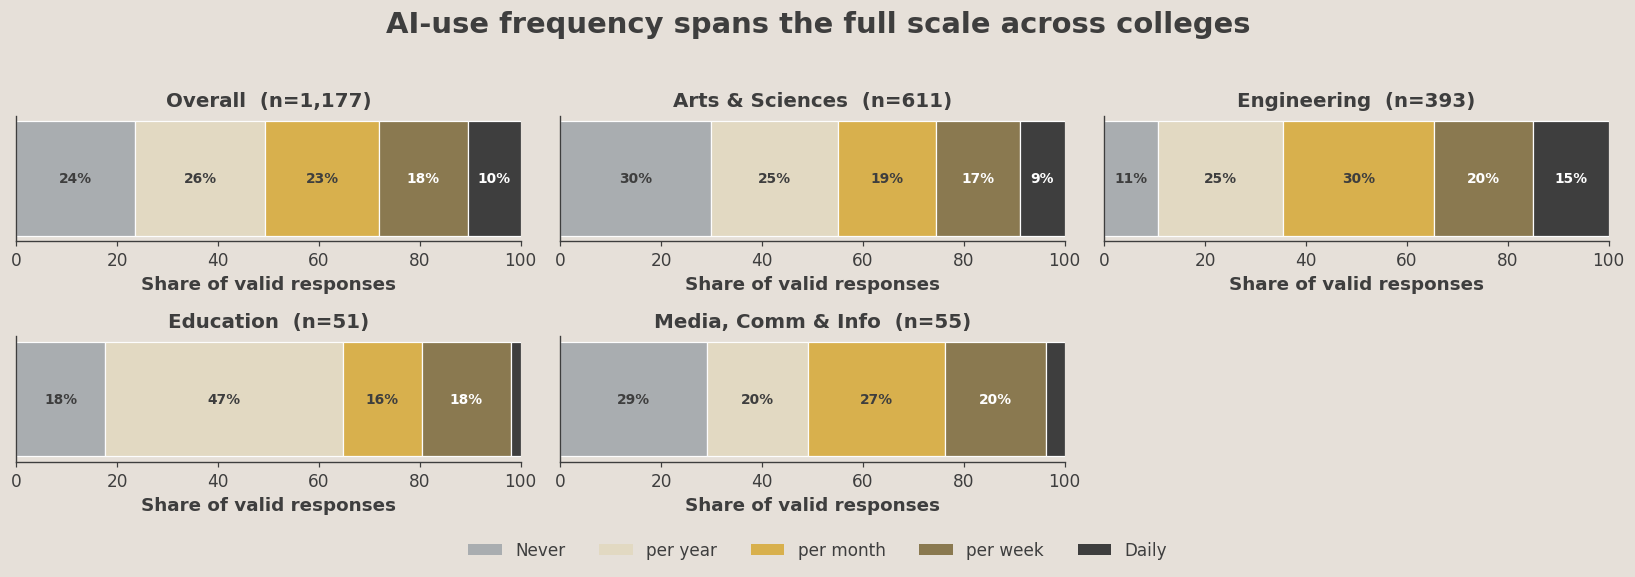

In [9]:
# Frequency distribution: one 100% bar per institution/college panel.
fig, axes = diagnostic_grid(len(diagnostic_colleges), panel_height=2.5)

for ax, college in zip(axes, diagnostic_colleges):
    subset = college_subset(ai_respondents, college)
    counts = subset[FREQUENCY].value_counts().reindex(FREQ_ORDER, fill_value=0)
    shares = 100 * counts / counts.sum()
    left = 0
    for response in FREQ_ORDER:
        width = shares[response]
        ax.barh(
            [0],
            [width],
            left=left,
            color=FREQ_COLORS[response],
            edgecolor="#FDFDFD",
            linewidth=0.8,
        )
        if width >= 8:
            ax.text(
                left + width / 2,
                0,
                f"{width:.0f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color="white" if response in WEEKLY_LEVELS else "#3E3E3E",
            )
        left += width
    ax.set_xlim(0, 100)
    ax.margins(x=0)
    ax.set_yticks([])
    ax.set_xlabel("Share of valid responses")
    ax.set_title(
        f"{college_title(college)}  (n={len(subset):,})",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

for ax in list(axes)[len(diagnostic_colleges):]:
    ax.remove()

handles = [
    Rectangle((0, 0), 1, 1, facecolor=FREQ_COLORS[value], edgecolor="none")
    for value in FREQ_ORDER
]
fig.suptitle(
    "AI-use frequency spans the full scale across colleges",
    fontsize=19,
    fontweight="bold",
    y=1.01,
)
fig.legend(
    handles,
    [value.replace("Several times ", "") for value in FREQ_ORDER],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.015),
    ncol=5,
    frameon=False,
)
fig.tight_layout(rect=(0, 0.06, 1, 0.98))
plt.show()

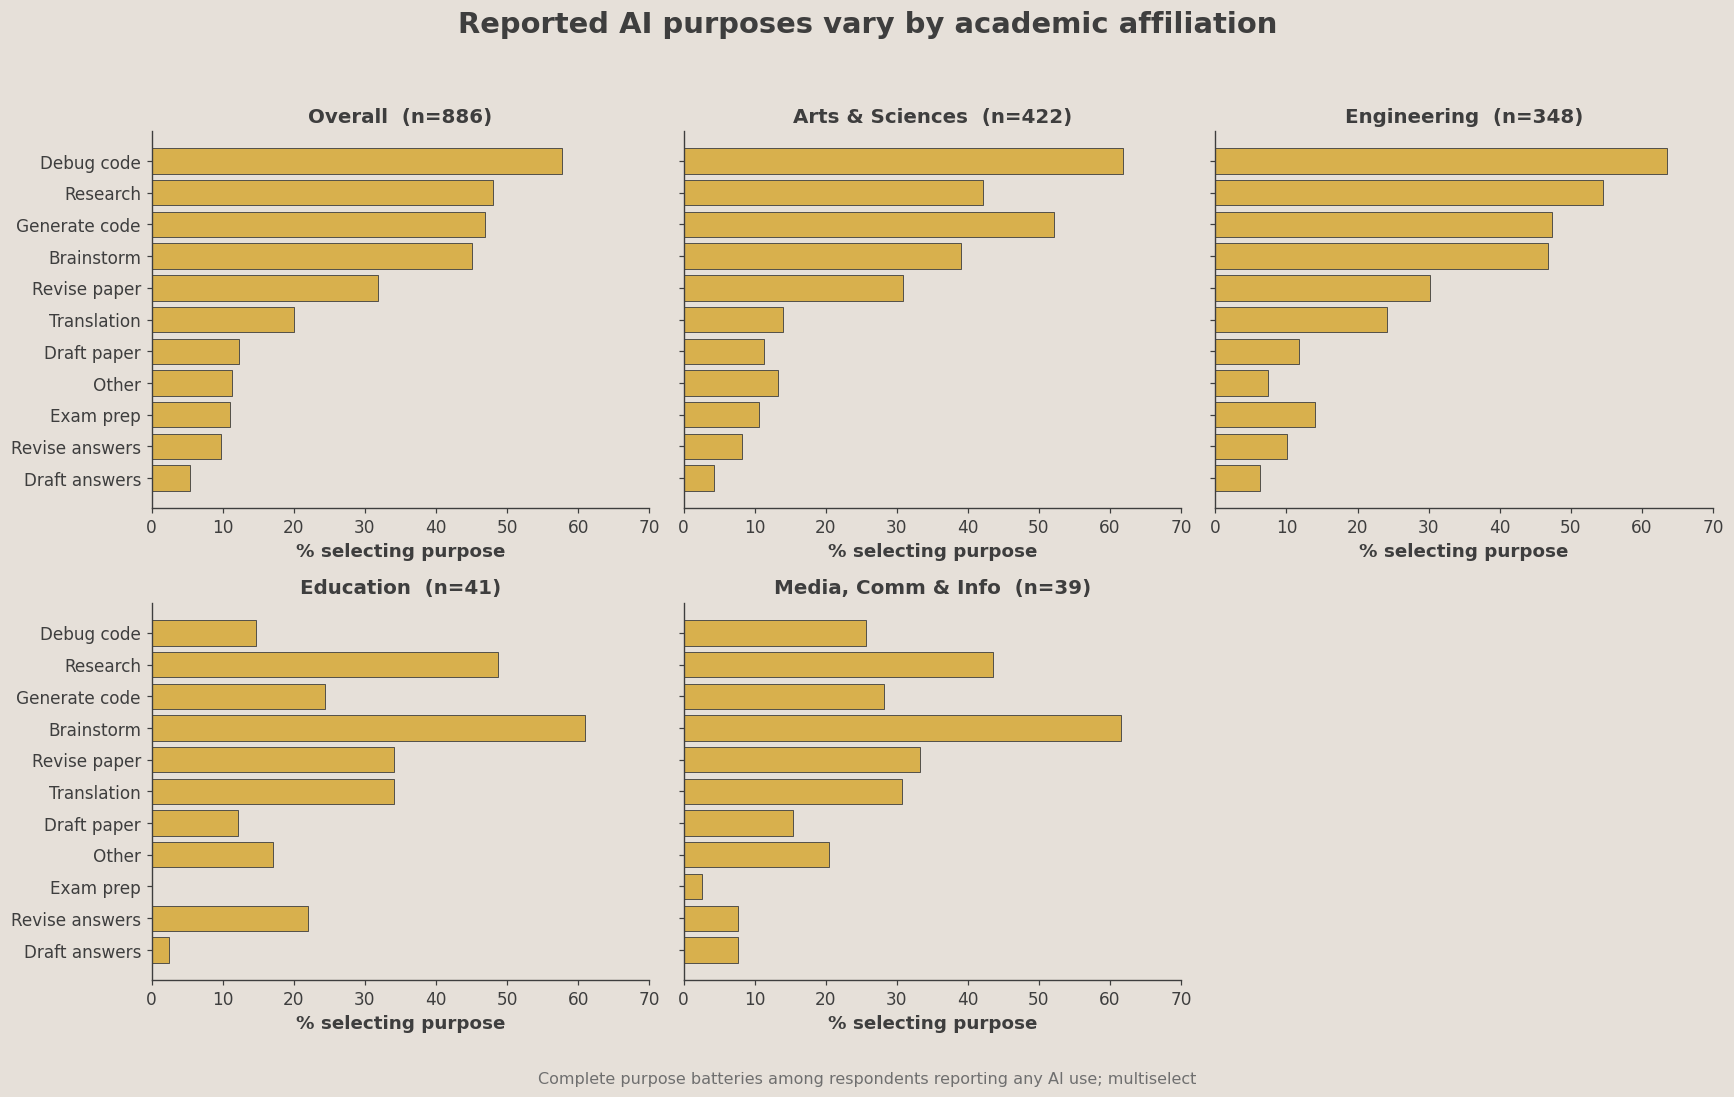

In [10]:
# Purpose distribution: every panel shows all 11 checkbox rates.
fig, axes = diagnostic_grid(
    len(diagnostic_colleges), panel_height=4.9, panel_width=5.3
)
purpose_order = (
    purpose_summary.sort_values("Percent")["code"].tolist()
)

for panel_index, (ax, college) in enumerate(zip(axes, diagnostic_colleges)):
    subset = college_subset(purpose_long, college)
    rates = (
        subset.groupby("code", observed=True)["Selected"]
        .mean()
        .mul(100)
        .reindex(purpose_order)
    )
    bases = subset.groupby("code", observed=True)["Selected"].size().reindex(purpose_order)
    y = np.arange(len(purpose_order))
    ax.barh(
        y,
        rates,
        color="#D8B04D",
        edgecolor="#3E3E3E",
        linewidth=0.55,
    )
    ax.set_xlim(0, 70)
    ax.margins(x=0)
    ax.set_xlabel("% selecting purpose")
    ax.set_title(
        f"{college_title(college)}  (n={int(bases.max()):,})",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_yticks(y)
    if panel_index % 3 == 0:
        ax.set_yticklabels([PURPOSE_SHORT[code] for code in purpose_order])
    else:
        ax.set_yticklabels([])
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

for ax in list(axes)[len(diagnostic_colleges):]:
    ax.remove()

fig.suptitle(
    "Reported AI purposes vary by academic affiliation",
    fontsize=19,
    fontweight="bold",
    y=1.01,
)
fig.text(
    0.5,
    0.015,
    "Complete purpose batteries among respondents reporting any AI use; multiselect",
    ha="center",
    fontsize=10.5,
    color="#6F6F6F",
)
fig.tight_layout(rect=(0, 0.045, 1, 0.98))
plt.show()

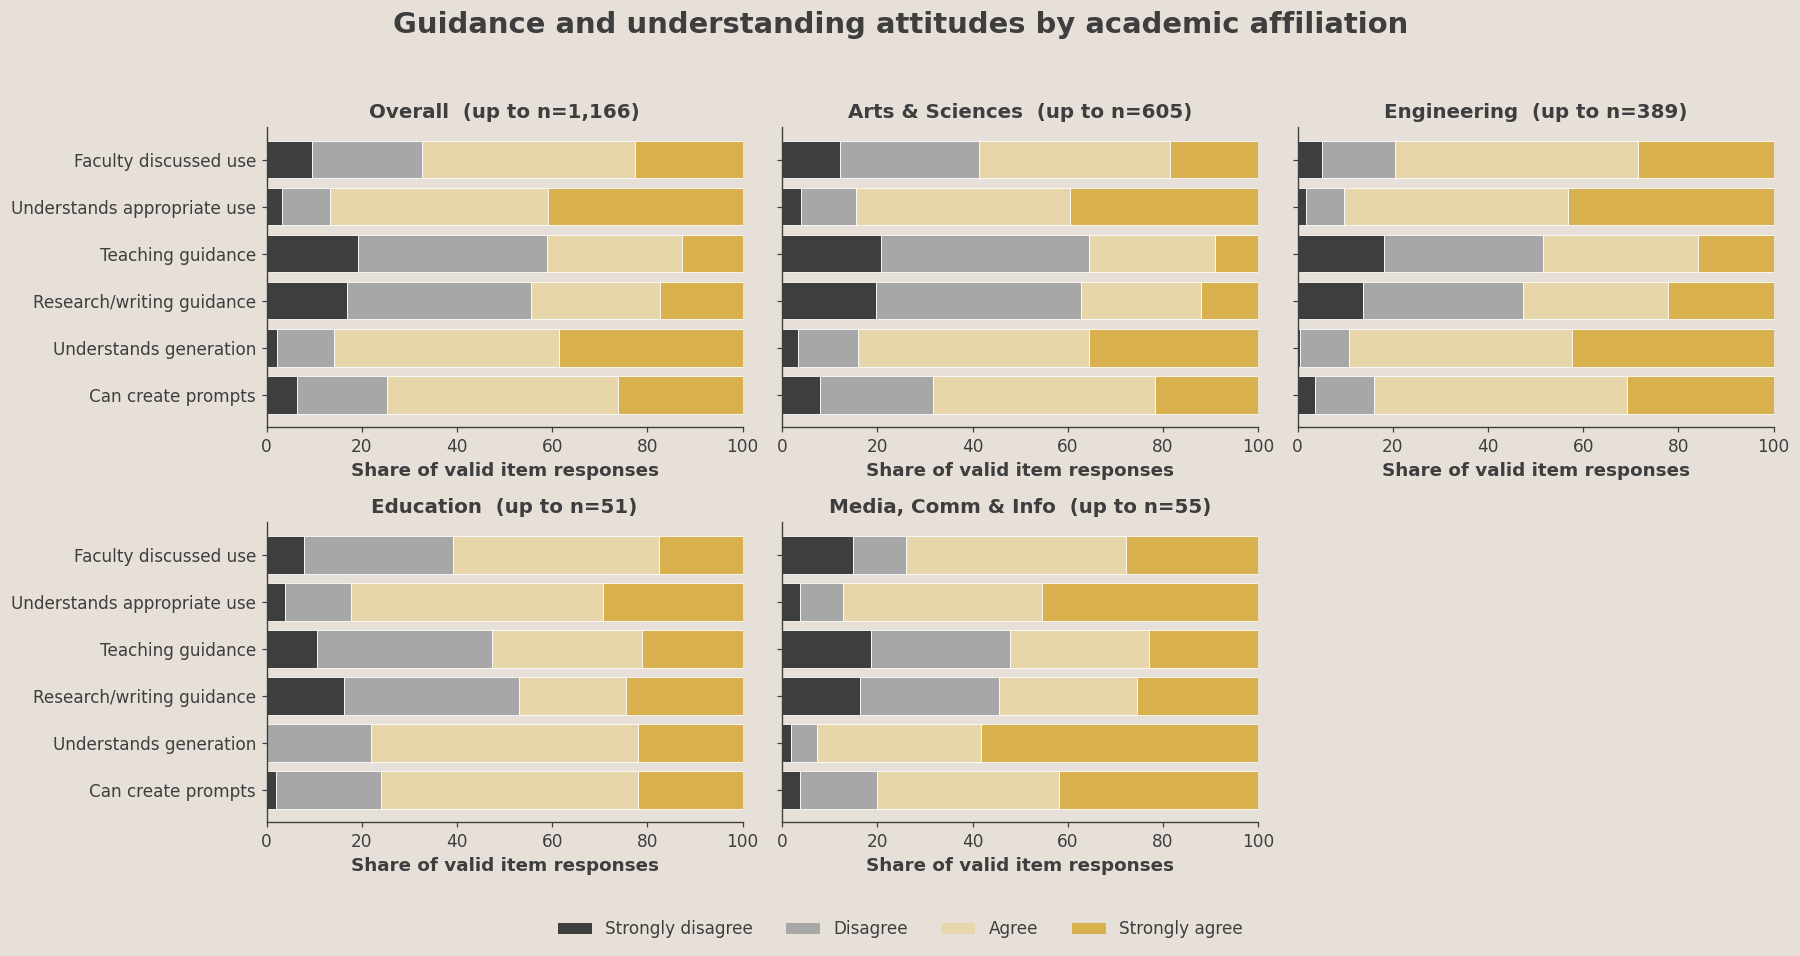

In [11]:
# Attitude distribution: six item-level Likert bars in every panel.
fig, axes = diagnostic_grid(
    len(diagnostic_colleges), panel_height=4.2, panel_width=5.5
)
attitude_code_order = list(ATTITUDE_LABELS)
attitude_short = {
    "GS1303_GSGAIPDC": "Faculty discussed use",
    "GS1303_GSGAIAUC": "Understands appropriate use",
    "GS1303_GSGAIGPT": "Teaching guidance",
    "GS1303_GSGAIGURW": "Research/writing guidance",
    "GS1303_GSGAIGR": "Understands generation",
    "GS1303_GSGAIEPDR": "Can create prompts",
}

for panel_index, (ax, college) in enumerate(zip(axes, diagnostic_colleges)):
    subset = college_subset(attitude_long, college)
    y = np.arange(len(attitude_code_order))
    left = np.zeros(len(attitude_code_order))
    for response in LIKERT_ORDER:
        response_rates = []
        for item_code in attitude_code_order:
            item = subset.loc[subset["code"].eq(item_code), "Response"]
            response_rates.append(100 * item.eq(response).mean() if len(item) else 0)
        ax.barh(
            y,
            response_rates,
            left=left,
            color=LIKERT_COLORS[response],
            edgecolor="#FDFDFD",
            linewidth=0.55,
        )
        left += np.asarray(response_rates)
    ax.set_xlim(0, 100)
    ax.margins(x=0)
    ax.set_xlabel("Share of valid item responses")
    respondent_n = subset["respondent_id"].nunique()
    ax.set_title(
        f"{college_title(college)}  (up to n={respondent_n:,})",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_yticks(y)
    if panel_index % 3 == 0:
        ax.set_yticklabels([attitude_short[code] for code in attitude_code_order])
    else:
        ax.set_yticklabels([])
    ax.invert_yaxis()
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

for ax in list(axes)[len(diagnostic_colleges):]:
    ax.remove()

handles = [
    Rectangle((0, 0), 1, 1, facecolor=LIKERT_COLORS[value], edgecolor="none")
    for value in LIKERT_ORDER
]
fig.suptitle(
    "Guidance and understanding attitudes by academic affiliation",
    fontsize=19,
    fontweight="bold",
    y=1.01,
)
fig.legend(
    handles,
    LIKERT_ORDER,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
    frameon=False,
)
fig.tight_layout(rect=(0, 0.055, 1, 0.98))
plt.show()

## 4. Leadership-facing figures

These are compact candidate figures for a 3–5 slide presentation. The more exhaustive grids
above are diagnostic support rather than required slide content.

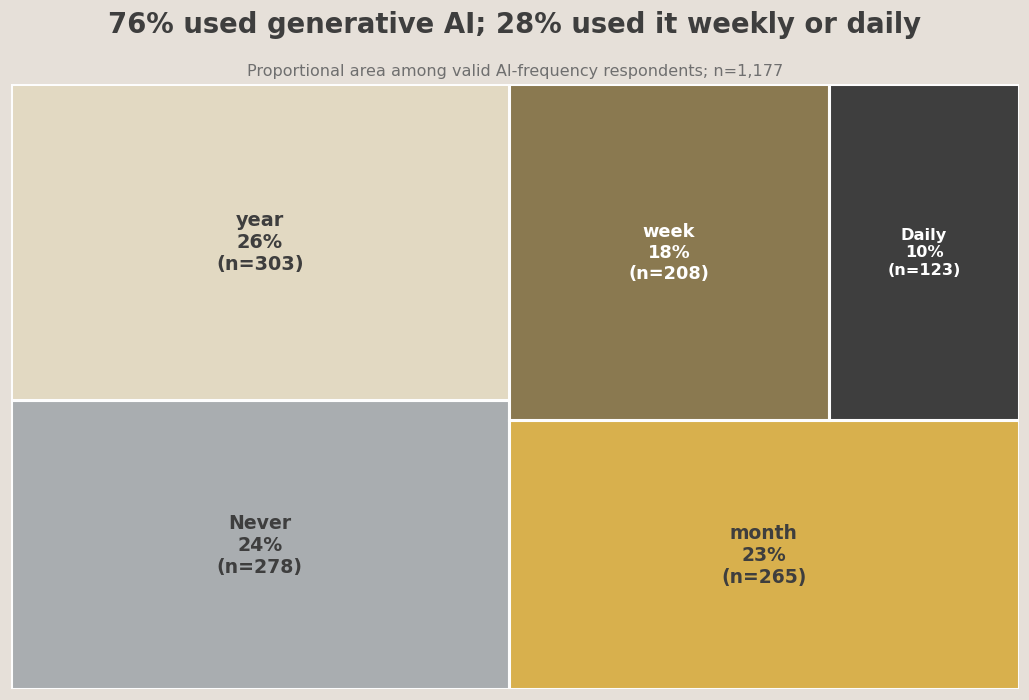

In [12]:
# A native binary treemap gives exact proportional area without a waffle grid.
def binary_treemap(values, labels, x=0, y=0, width=100, height=60):
    # Recursively partition a rectangle; each tile area equals its value share.
    values = np.asarray(values, dtype=float)
    if len(values) == 1:
        return [(x, y, width, height, labels[0], values[0])]

    cumulative = np.cumsum(values)
    split = int(np.argmin(np.abs(cumulative[:-1] - values.sum() / 2))) + 1
    first_total = values[:split].sum()
    ratio = first_total / values.sum()

    if width >= height:
        first_width = width * ratio
        return binary_treemap(
            values[:split], labels[:split], x, y, first_width, height
        ) + binary_treemap(
            values[split:],
            labels[split:],
            x + first_width,
            y,
            width - first_width,
            height,
        )
    first_height = height * ratio
    return binary_treemap(
        values[:split], labels[:split], x, y, width, first_height
    ) + binary_treemap(
        values[split:],
        labels[split:],
        x,
        y + first_height,
        width,
        height - first_height,
    )


tiles = binary_treemap(
    frequency_summary["Respondents"].to_numpy(),
    frequency_summary["Frequency"].tolist(),
)
ever_used = 100 * ai_respondents[FREQUENCY].ne("Never").mean()
weekly_used = 100 * ai_respondents["weekly_or_more"].mean()

fig, ax = plt.subplots(figsize=(12, 6.5))
for x, y, width, height, label, count in tiles:
    percent = 100 * count / len(ai_respondents)
    ax.add_patch(
        Rectangle(
            (x, y),
            width,
            height,
            facecolor=FREQ_COLORS[label],
            edgecolor="#FDFDFD",
            linewidth=2,
        )
    )
    text_color = "white" if label in WEEKLY_LEVELS else "#3E3E3E"
    label_text = label.replace("Several times per ", "")
    ax.text(
        x + width / 2,
        y + height / 2,
        f"{label_text}\n{percent:.0f}%\n(n={int(count):,})",
        ha="center",
        va="center",
        color=text_color,
        fontweight="bold",
        fontsize=max(9, min(15, 7 + np.sqrt(width * height) / 7)),
    )

ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.margins(0)
ax.set_aspect("equal")
ax.axis("off")
add_title(
    ax,
    f"{ever_used:.0f}% used generative AI; {weekly_used:.0f}% used it weekly or daily",
    f"Proportional area among valid AI-frequency respondents; n={len(ai_respondents):,}",
    pad=34,
)
plt.tight_layout()
plt.show()

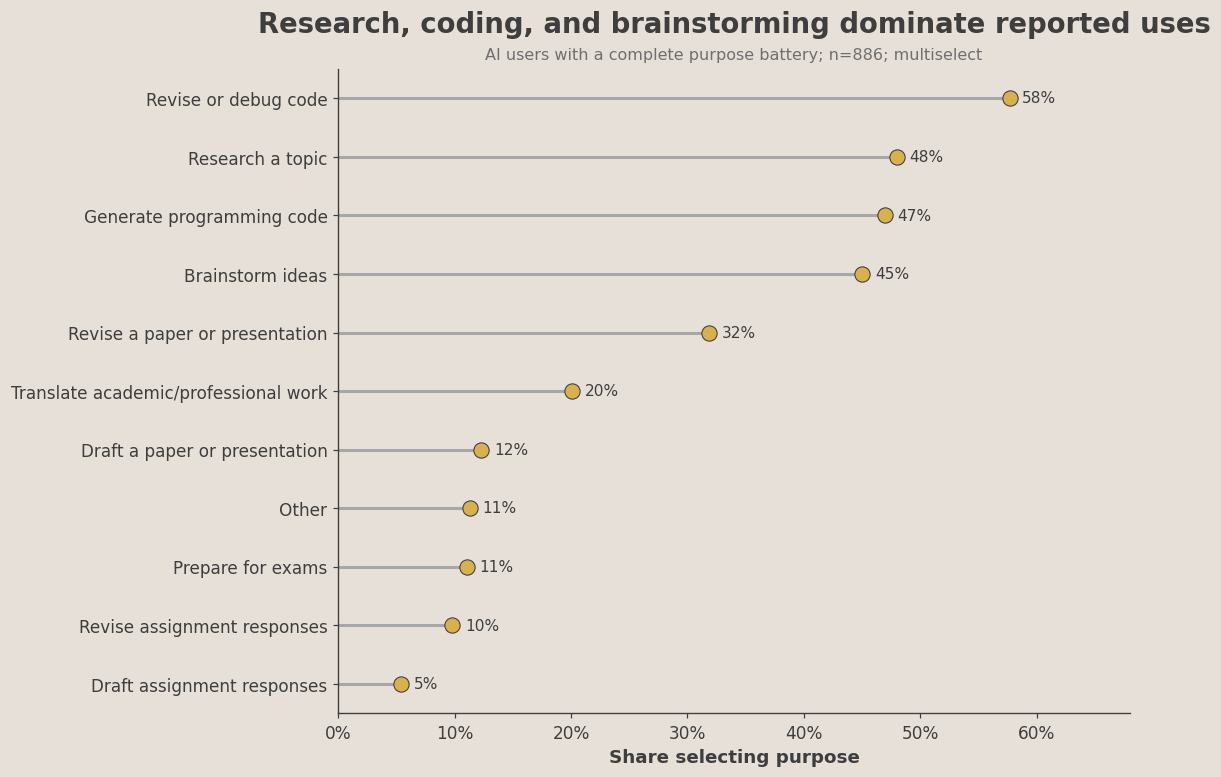

In [13]:
# Purpose prevalence: a compact lollipop retains exact rates without bar-chart weight.
plot_data = purpose_summary.sort_values("Percent").reset_index(drop=True)
y = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(10.5, 7.2))
ax.hlines(y, 0, plot_data["Percent"], color="#A7A7A7", linewidth=2)
ax.scatter(
    plot_data["Percent"],
    y,
    s=100,
    color="#D8B04D",
    edgecolor="#3E3E3E",
    linewidth=0.7,
    zorder=3,
)
for y_value, percent in zip(y, plot_data["Percent"]):
    ax.text(percent + 1.1, y_value, f"{percent:.0f}%", va="center", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(plot_data["Purpose"])
ax.set_xlim(0, 68)
ax.margins(x=0)
ax.set_xlabel("Share selecting purpose")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
add_title(
    ax,
    "Research, coding, and brainstorming dominate reported uses",
    f"AI users with a complete purpose battery; n={len(purpose_base):,}; multiselect",
)
plt.tight_layout()
plt.show()

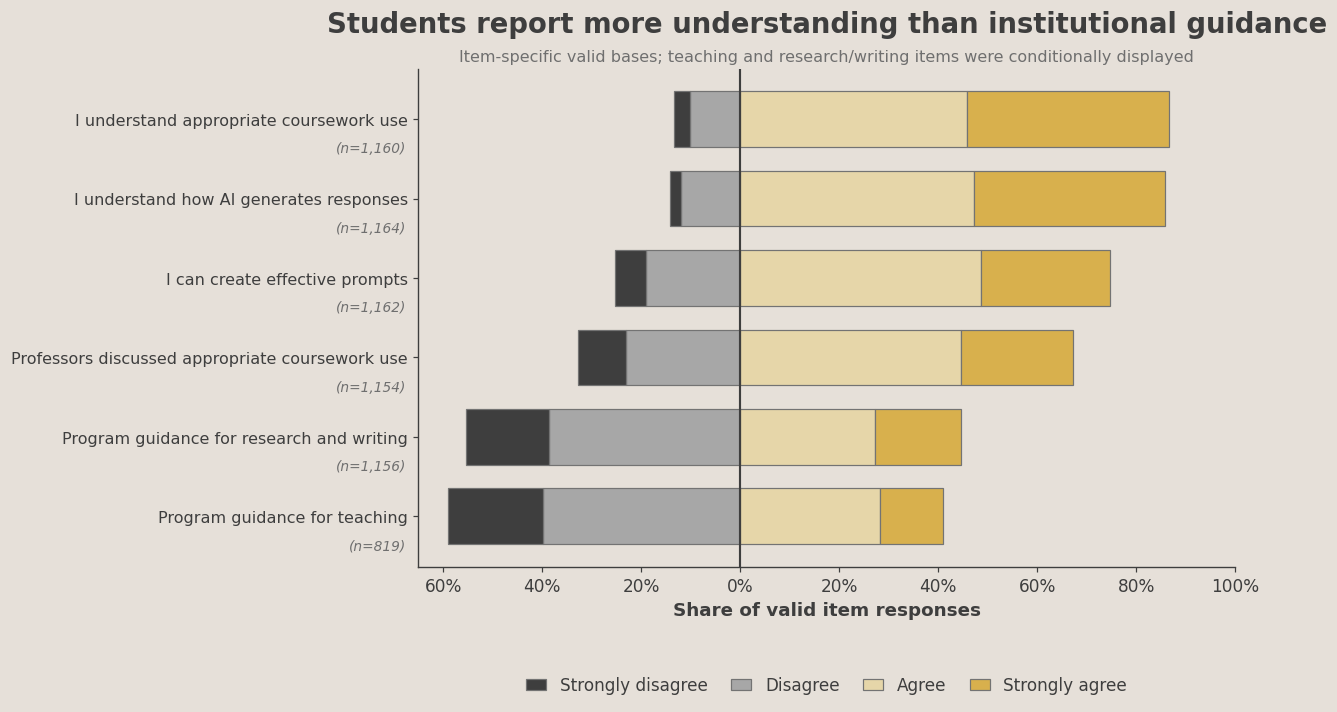

In [14]:
# Divergent Likert: disagreement extends left, with each item's base directly attached.
attitude_topbox = (
    attitude_long.assign(
        Agree=lambda frame: frame["Response"].isin(["Agree", "Strongly agree"])
    )
    .groupby(["code", "Item"], observed=True)["Agree"]
    .agg(["mean", "size"])
    .reset_index()
    .rename(columns={"mean": "TopBox", "size": "ItemBase"})
    .sort_values("TopBox")
)
item_order = attitude_topbox["code"].tolist()
y = np.arange(len(item_order))

fig, ax = plt.subplots(figsize=(13.5, 7.3))
negative_left = np.zeros(len(item_order))
positive_left = np.zeros(len(item_order))

# Draw Disagree first so it sits next to zero; Strongly disagree remains outermost.
for response in ["Disagree", "Strongly disagree"]:
    widths = (
        attitude_distribution.loc[
            attitude_distribution["Response"].eq(response)
        ]
        .set_index("code")["Percent"]
        .reindex(item_order, fill_value=0)
        .to_numpy()
    )
    ax.barh(
        y,
        -widths,
        left=negative_left,
        color=LIKERT_COLORS[response],
        edgecolor="#737373",
        linewidth=0.8,
        height=0.7,
    )
    negative_left -= widths

for response in ["Agree", "Strongly agree"]:
    widths = (
        attitude_distribution.loc[
            attitude_distribution["Response"].eq(response)
        ]
        .set_index("code")["Percent"]
        .reindex(item_order, fill_value=0)
        .to_numpy()
    )
    ax.barh(
        y,
        widths,
        left=positive_left,
        color=LIKERT_COLORS[response],
        edgecolor="#737373",
        linewidth=0.8,
        height=0.7,
    )
    positive_left += widths

ax.axvline(0, color="#3E3E3E", linewidth=1.4)
ax.set_yticks(y)
ax.set_yticklabels(
    [ATTITUDE_LABELS[code] for code in item_order],
    fontsize=10.5,
)
for y_value, item_code in zip(y, item_order):
    item_n = int(
        attitude_topbox.loc[
            attitude_topbox["code"].eq(item_code), "ItemBase"
        ].iloc[0]
    )
    ax.text(
        -0.015,
        y_value - 0.28,
        f"(n={item_n:,})",
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="top",
        fontsize=9,
        fontstyle="italic",
        color="#6F6F6F",
    )

ax.set_xlim(-65, 100)
ax.margins(x=0)
ax.set_xlabel("Share of valid item responses")
ax.xaxis.set_major_formatter(lambda value, position: f"{abs(value):.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
handles = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor=LIKERT_COLORS[value],
        edgecolor="#737373",
        linewidth=0.8,
    )
    for value in LIKERT_ORDER
]
legend_below(ax, handles, LIKERT_ORDER, ncol=4, y=-0.19)
add_title(
    ax,
    "Students report more understanding than institutional guidance",
    "Item-specific valid bases; teaching and research/writing items were conditionally displayed",
)
plt.subplots_adjust(left=0.35, bottom=0.22, top=0.84)
plt.show()

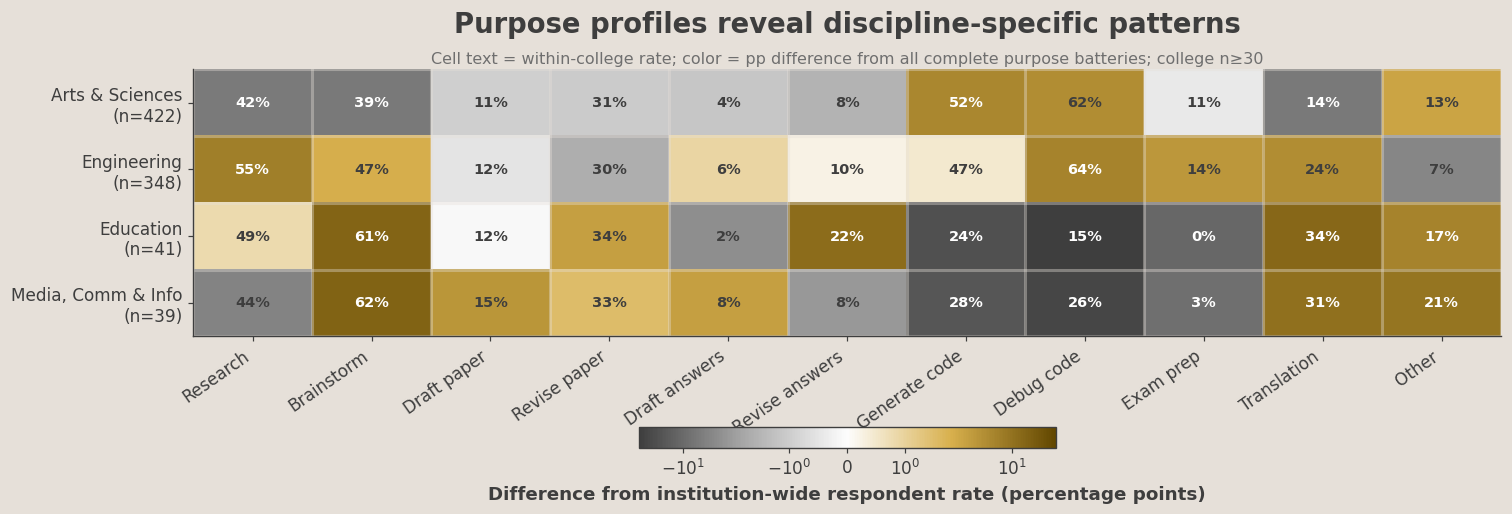

In [15]:
# College-purpose heatmap: text is rate; color emphasizes even small pp differences.
purpose_short_order = [PURPOSE_SHORT[code] for code in PURPOSE_COLUMNS]
college_order = (
    college_bases.loc[eligible_colleges]
    .sort_values(ascending=False)
    .index.to_series()
    .map(COLLEGE_SHORT)
    .tolist()
)
rate_matrix = (
    college_purpose.pivot(index="College", columns="PurposeShort", values="Percent")
    .reindex(index=college_order, columns=purpose_short_order)
)
delta_matrix = (
    college_purpose.pivot(index="College", columns="PurposeShort", values="Delta")
    .reindex(index=college_order, columns=purpose_short_order)
)

color_map = LinearSegmentedColormap.from_list(
    "cu_diverging",
    ["#3E3E3E", "#A7A7A7", "#FDFDFD", "#D8B04D", "#624700"],
)
extent = max(abs(delta_matrix.min().min()), abs(delta_matrix.max().max()))
normalizer = SymLogNorm(
    linthresh=2,
    linscale=1.5,
    vmin=-extent,
    vmax=extent,
    base=10,
)

fig, ax = plt.subplots(figsize=(14.5, 6.5))
image = ax.imshow(
    delta_matrix.to_numpy(),
    cmap=color_map,
    norm=normalizer,
    aspect="auto",
)
for row in range(rate_matrix.shape[0]):
    for column in range(rate_matrix.shape[1]):
        delta = delta_matrix.iat[row, column]
        ax.text(
            column,
            row,
            f"{rate_matrix.iat[row, column]:.0f}%",
            ha="center",
            va="center",
            fontsize=9.5,
            fontweight="bold",
            color="white" if abs(delta) >= 5 else "#3E3E3E",
        )

college_labels = [
    f"{college}\n(n={int(college_bases.loc[name]):,})"
    for name, college in zip(
        college_bases.loc[eligible_colleges].sort_values(ascending=False).index,
        college_order,
    )
]
ax.set_xticks(np.arange(len(purpose_short_order)))
ax.set_xticklabels(purpose_short_order, rotation=35, ha="right")
ax.set_yticks(np.arange(len(college_order)))
ax.set_yticklabels(college_labels)
ax.grid(False)
ax.set_xticks(np.arange(-0.5, len(purpose_short_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(college_order), 1), minor=True)
ax.grid(which="minor", color="#E6E0D9", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)
add_title(
    ax,
    "Purpose profiles reveal discipline-specific patterns",
    "Cell text = within-college rate; color = pp difference from all complete purpose batteries; college n≥30",
)
colorbar = fig.colorbar(
    image,
    ax=ax,
    orientation="horizontal",
    fraction=0.055,
    pad=0.24,
    shrink=0.62,
)
colorbar.set_label("Difference from institution-wide respondent rate (percentage points)")
plt.subplots_adjust(bottom=0.29, top=0.82, left=0.16, right=0.98)
plt.show()

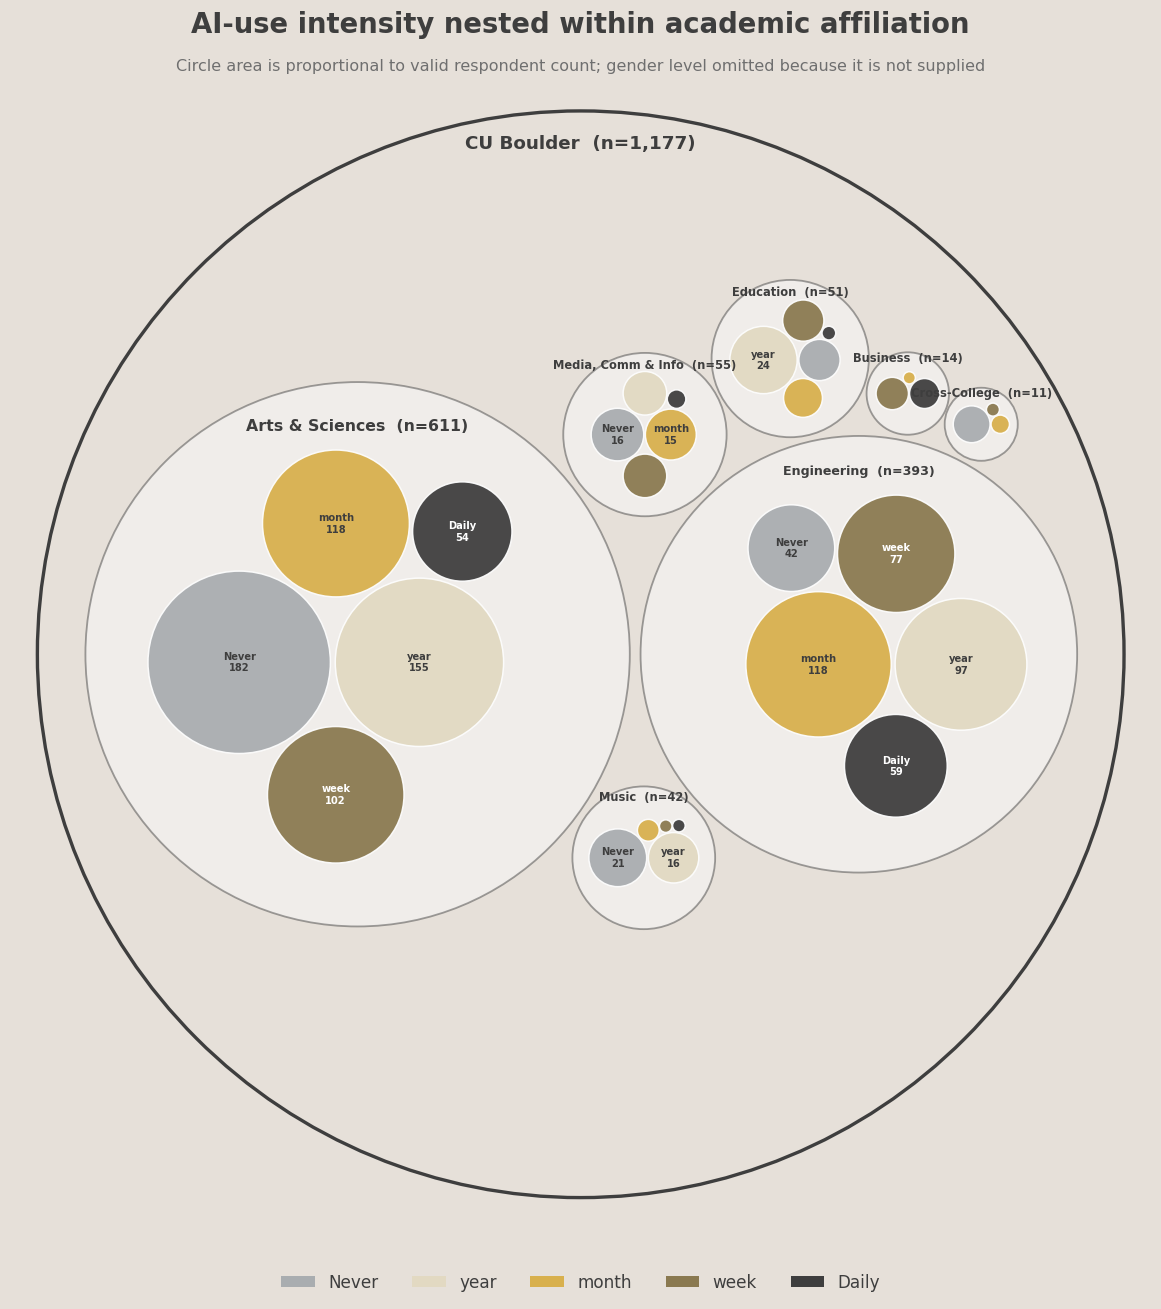

In [16]:
# Hierarchical circle pack: CU Boulder → college → frequency.
# Gender was requested as an intermediate level, but the supplied file contains no gender field.
def pack_circles(values, padding=0.02):
    # Pack fixed-area circles by placing each new circle tangent to two earlier circles.
    values = np.asarray(values, dtype=float)
    base_radii = np.sqrt(values)
    order = np.argsort(-base_radii)
    radii = base_radii[order]
    placed = [np.array([0.0, 0.0])]
    if len(radii) > 1:
        placed.append(np.array([radii[0] + radii[1] + padding, 0.0]))

    def tangent_candidates(center_a, radius_a, center_b, radius_b, radius):
        distance_a = radius_a + radius + padding
        distance_b = radius_b + radius + padding
        delta = center_b - center_a
        distance = np.linalg.norm(delta)
        if distance == 0 or distance > distance_a + distance_b:
            return []
        along = (
            distance_a**2 - distance_b**2 + distance**2
        ) / (2 * distance)
        height_sq = max(distance_a**2 - along**2, 0)
        base = center_a + along * delta / distance
        perpendicular = np.array([-delta[1], delta[0]]) / distance
        height = np.sqrt(height_sq)
        return [base + height * perpendicular, base - height * perpendicular]

    for new_index in range(2, len(radii)):
        radius = radii[new_index]
        candidates = []
        for i in range(new_index):
            for j in range(i + 1, new_index):
                for candidate in tangent_candidates(
                    placed[i],
                    radii[i],
                    placed[j],
                    radii[j],
                    radius,
                ):
                    if all(
                        np.linalg.norm(candidate - placed[k])
                        >= radius + radii[k] + padding - 1e-8
                        for k in range(new_index)
                    ):
                        candidates.append(candidate)
        if not candidates:
            # Rare fallback: walk an expanding golden-angle spiral until clear.
            for step in range(1, 10000):
                angle = step * np.pi * (3 - np.sqrt(5))
                distance = np.sqrt(step) * (radius + padding)
                candidate = distance * np.array([np.cos(angle), np.sin(angle)])
                if all(
                    np.linalg.norm(candidate - placed[k])
                    >= radius + radii[k] + padding
                    for k in range(new_index)
                ):
                    candidates.append(candidate)
                    break

        def candidate_score(candidate):
            centers = placed + [candidate]
            candidate_radii = radii[: new_index + 1]
            center_guess = np.average(
                np.asarray(centers),
                axis=0,
                weights=candidate_radii**2,
            )
            return max(
                np.linalg.norm(center - center_guess) + circle_radius
                for center, circle_radius in zip(centers, candidate_radii)
            )

        placed.append(min(candidates, key=candidate_score))

    positions = np.asarray(placed)

    def enclosing_radius(center):
        return max(
            np.linalg.norm(position - center) + radius
            for position, radius in zip(positions, radii)
        )

    center_guess = np.average(positions, axis=0, weights=radii**2)
    fitted_center = minimize(
        enclosing_radius,
        center_guess,
        method="Nelder-Mead",
        options={"maxiter": 2000, "xatol": 1e-10, "fatol": 1e-10},
    ).x
    enclosing = enclosing_radius(fitted_center)
    positions = (positions - fitted_center) / enclosing
    radii = radii / enclosing
    inverse = np.argsort(order)
    return positions[inverse], radii[inverse]


circle_counts = (
    ai_respondents.dropna(subset=["COLLEGE_NAME1", FREQUENCY])
    .groupby(["COLLEGE_NAME1", FREQUENCY], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
college_totals = (
    circle_counts.groupby("COLLEGE_NAME1", observed=True)["n"]
    .sum()
    .sort_values(ascending=False)
)
college_positions, college_radii = pack_circles(college_totals.to_numpy())

fig, ax = plt.subplots(figsize=(12, 12))
ax.add_patch(Circle((0, 0), 1.03, facecolor="none", edgecolor="#3E3E3E", linewidth=2.2))
ax.text(
    0,
    0.985,
    f"CU Boulder  (n={len(ai_respondents):,})",
    ha="center",
    va="top",
    fontsize=12,
    fontweight="bold",
)

for (college, college_n), position, radius in zip(
    college_totals.items(), college_positions, college_radii
):
    cx, cy = position * 0.95
    radius *= 0.93
    ax.add_patch(
        Circle(
            (cx, cy),
            radius,
            facecolor="#FDFDFD",
            edgecolor="#3E3E3E",
            linewidth=1.2,
            alpha=0.48,
        )
    )

    frequency_counts = (
        circle_counts.loc[circle_counts["COLLEGE_NAME1"].eq(college)]
        .set_index(FREQUENCY)["n"]
        .reindex(FREQ_ORDER, fill_value=0)
    )
    positive = frequency_counts.loc[frequency_counts.gt(0)]
    child_positions, child_radii = pack_circles(
        positive.to_numpy(), padding=0.035
    )
    for (frequency, count), child_position, child_radius in zip(
        positive.items(), child_positions, child_radii
    ):
        child_x, child_y = np.array([cx, cy]) + child_position * radius * 0.78
        child_radius *= radius * 0.76
        ax.add_patch(
            Circle(
                (child_x, child_y),
                child_radius,
                facecolor=FREQ_COLORS[frequency],
                edgecolor="#FDFDFD",
                linewidth=1,
                alpha=0.94,
            )
        )
        if child_radius > 0.045:
            ax.text(
                child_x,
                child_y,
                f"{frequency.replace('Several times per ', '')}\n{int(count):,}",
                ha="center",
                va="center",
                fontsize=max(6.5, min(9.5, child_radius * 30)),
                color="white" if frequency in WEEKLY_LEVELS else "#3E3E3E",
                fontweight="bold",
            )

    ax.text(
        cx,
        cy + radius * 0.84,
        f"{COLLEGE_SHORT[college]}  (n={int(college_n):,})",
        ha="center",
        va="center",
        fontsize=max(7.5, min(12, radius * 20)),
        fontweight="bold",
    )

ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)
ax.set_aspect("equal")
ax.axis("off")
add_title(
    ax,
    "AI-use intensity nested within academic affiliation",
    "Circle area is proportional to valid respondent count; gender level omitted because it is not supplied",
    pad=34,
)
handles = [
    Circle((0, 0), 0.1, facecolor=FREQ_COLORS[value], edgecolor="none")
    for value in FREQ_ORDER
]
ax.legend(
    handles,
    [value.replace("Several times per ", "") for value in FREQ_ORDER],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=5,
    frameon=False,
)
plt.tight_layout()
plt.show()

## 5. Diagnostic appendix

These checks quantify uncertainty in small college samples and test whether the college
frequency pattern is largely a composition effect from the unlabeled `LEVEL_GRAD` codes.
They are useful for interview discussion but do not all need to appear in the deck.

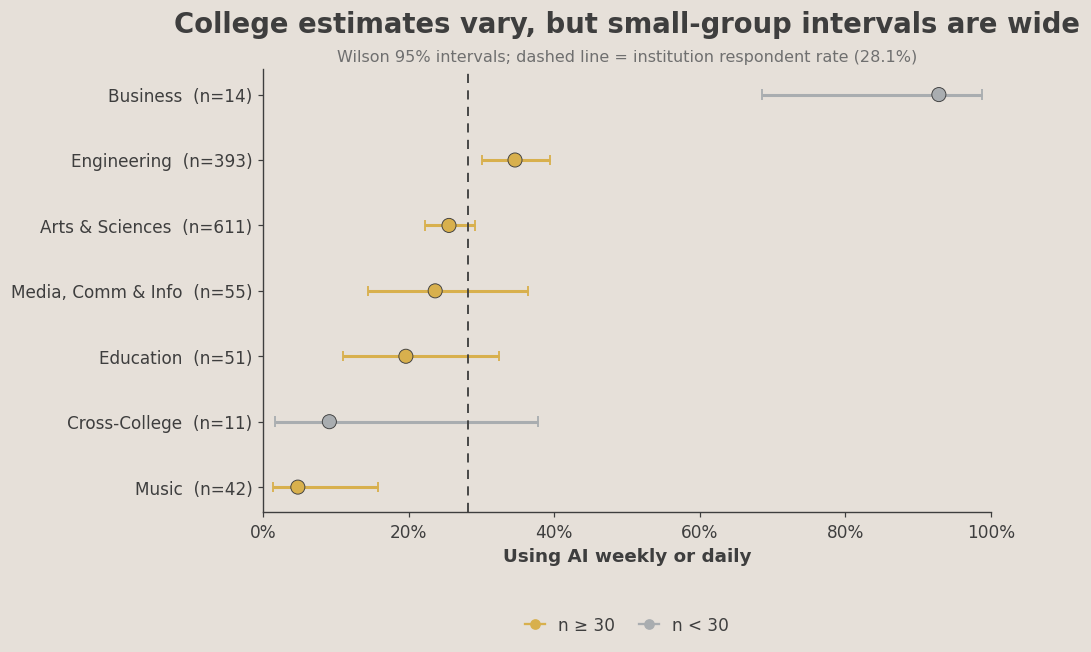

In [17]:
# Weekly-or-more use by college with Wilson 95% intervals and sample-size signaling.
college_weekly = (
    ai_respondents.groupby(["COLLEGE_CODE1", "COLLEGE_NAME1"], observed=True)
    .agg(
        Respondents=(FREQUENCY, "size"),
        Weekly=("weekly_or_more", "sum"),
        Percent=("weekly_or_more", "mean"),
    )
    .reset_index()
)
college_weekly["Percent"] *= 100

z = 1.96
p = college_weekly["Weekly"] / college_weekly["Respondents"]
denominator = 1 + z**2 / college_weekly["Respondents"]
center = (p + z**2 / (2 * college_weekly["Respondents"])) / denominator
half_width = (
    z
    * np.sqrt(
        p * (1 - p) / college_weekly["Respondents"]
        + z**2 / (4 * college_weekly["Respondents"] ** 2)
    )
    / denominator
)
college_weekly["Lower"] = 100 * (center - half_width)
college_weekly["Upper"] = 100 * (center + half_width)
college_weekly["College"] = college_weekly["COLLEGE_NAME1"].map(COLLEGE_SHORT)
college_weekly["SampleFlag"] = np.where(
    college_weekly["Respondents"].ge(30), "n ≥ 30", "n < 30"
)
college_weekly = college_weekly.sort_values("Percent")
institution_weekly = 100 * ai_respondents["weekly_or_more"].mean()

fig, ax = plt.subplots(figsize=(10.5, 6.5))
y = np.arange(len(college_weekly))
colors = college_weekly["SampleFlag"].map(
    {"n ≥ 30": "#D8B04D", "n < 30": "#A9ADB0"}
)
for y_value, (_, row), color in zip(y, college_weekly.iterrows(), colors):
    ax.hlines(
        y_value,
        row["Lower"],
        row["Upper"],
        color=color,
        linewidth=2,
    )
    ax.vlines(
        [row["Lower"], row["Upper"]],
        y_value - 0.08,
        y_value + 0.08,
        color=color,
        linewidth=1.2,
    )
ax.scatter(
    college_weekly["Percent"],
    y,
    c=colors,
    s=85,
    edgecolor="#3E3E3E",
    linewidth=0.6,
    zorder=3,
)
ax.axvline(
    institution_weekly,
    color="#3E3E3E",
    linestyle=(0, (5, 4)),
    linewidth=1.2,
)
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{college}  (n={n:,})"
        for college, n in zip(
            college_weekly["College"], college_weekly["Respondents"]
        )
    ]
)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.set_xlabel("Using AI weekly or daily")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
handles = [
    Line2D([0], [0], marker="o", color="#D8B04D", linestyle="-", label="n ≥ 30"),
    Line2D([0], [0], marker="o", color="#A9ADB0", linestyle="-", label="n < 30"),
]
legend_below(ax, handles, ["n ≥ 30", "n < 30"], ncol=2, y=-0.2)
add_title(
    ax,
    "College estimates vary, but small-group intervals are wide",
    f"Wilson 95% intervals; dashed line = institution respondent rate ({institution_weekly:.1f}%)",
)
plt.subplots_adjust(left=0.27, bottom=0.2, top=0.82)
plt.show()

College,n,Observed,Adjusted,Change
Business,14,92.9%,92.5%,-0.4 pp
Engineering,393,34.6%,34.6%,-0.0 pp
Arts & Sciences,611,25.5%,25.3%,-0.3 pp
"Media, Comm & Info",55,23.6%,23.7%,+0.0 pp
Education,51,19.6%,21.2%,+1.6 pp
Cross-College,11,9.1%,11.0%,+1.9 pp
Music,42,4.8%,4.9%,+0.2 pp


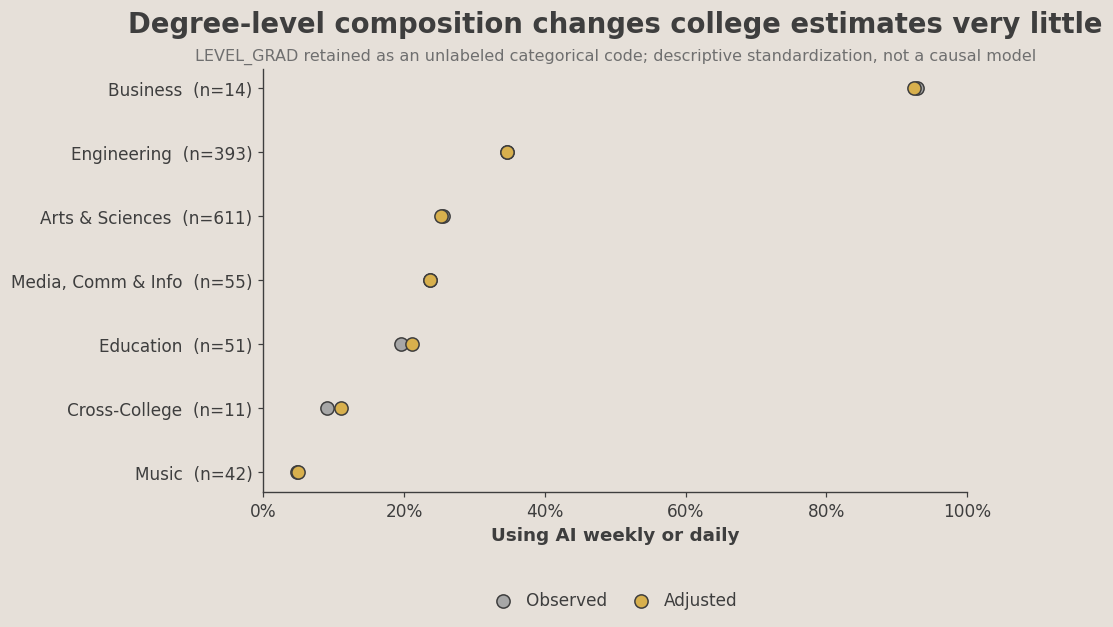

In [18]:
# Descriptive composition check using unpenalized logistic standardization.
model_data = ai_respondents.dropna(
    subset=["COLLEGE_CODE1", "COLLEGE_NAME1", "LEVEL_GRAD"]
).copy()
model_data["weekly"] = model_data["weekly_or_more"].astype(int)
model_data["level_code"] = model_data["LEVEL_GRAD"].astype(int).astype(str)

design = pd.get_dummies(
    model_data[["COLLEGE_CODE1", "level_code"]].astype(str),
    drop_first=False,
    dtype=float,
)
with warnings.catch_warnings():
    # sklearn 1.8 emits a redundant transition warning for its documented C=np.inf route.
    warnings.filterwarnings(
        "ignore",
        message="Setting penalty=None will ignore.*",
        category=UserWarning,
    )
    weekly_model = LogisticRegression(
        C=np.inf,
        l1_ratio=0,
        solver="lbfgs",
        max_iter=2000,
    ).fit(design, model_data["weekly"])

adjusted_rows = []
for college_code, college_name in (
    model_data[["COLLEGE_CODE1", "COLLEGE_NAME1"]]
    .drop_duplicates()
    .sort_values("COLLEGE_CODE1")
    .itertuples(index=False)
):
    scenario = model_data[["COLLEGE_CODE1", "level_code"]].astype(str).copy()
    scenario["COLLEGE_CODE1"] = college_code
    scenario_design = pd.get_dummies(
        scenario,
        drop_first=False,
        dtype=float,
    ).reindex(columns=design.columns, fill_value=0)
    college_observed = model_data.loc[
        model_data["COLLEGE_CODE1"].eq(college_code)
    ]
    adjusted_rows.append(
        {
            "College": COLLEGE_SHORT[college_name],
            "n": len(college_observed),
            "Observed": 100 * college_observed["weekly"].mean(),
            "Adjusted": 100 * weekly_model.predict_proba(scenario_design)[:, 1].mean(),
        }
    )

college_adjustment = pd.DataFrame(adjusted_rows)
college_adjustment["Change"] = (
    college_adjustment["Adjusted"] - college_adjustment["Observed"]
)
college_adjustment = college_adjustment.sort_values("Observed")

display(
    style_table(
        college_adjustment.sort_values("Observed", ascending=False),
        (
            "Degree-level composition check; maximum absolute adjustment = "
            f"{college_adjustment['Change'].abs().max():.1f} percentage points"
        ),
        {
            "n": "{:,.0f}",
            "Observed": "{:.1f}%",
            "Adjusted": "{:.1f}%",
            "Change": "{:+.1f} pp",
        },
    )
)

fig, ax = plt.subplots(figsize=(10, 6.2))
y = np.arange(len(college_adjustment))
ax.hlines(
    y,
    college_adjustment["Observed"],
    college_adjustment["Adjusted"],
    color="#A7A7A7",
    linewidth=2,
)
ax.scatter(
    college_adjustment["Observed"],
    y,
    color="#A7A7A7",
    edgecolor="#3E3E3E",
    s=75,
    label="Observed",
    zorder=3,
)
ax.scatter(
    college_adjustment["Adjusted"],
    y,
    color="#D8B04D",
    edgecolor="#3E3E3E",
    s=75,
    label="Adjusted",
    zorder=3,
)
ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{college}  (n={n:,})"
        for college, n in zip(
            college_adjustment["College"], college_adjustment["n"]
        )
    ]
)
ax.set_xlim(0, 100)
ax.margins(x=0)
ax.set_xlabel("Using AI weekly or daily")
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0f}%")
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
legend_below(ax, ncol=2, y=-0.2)
add_title(
    ax,
    "Degree-level composition changes college estimates very little",
    "LEVEL_GRAD retained as an unlabeled categorical code; descriptive standardization, not a causal model",
)
plt.subplots_adjust(left=0.26, bottom=0.2, top=0.82)
plt.show()

In [19]:
# Metadata audit: retain codes until an authoritative crosswalk is supplied.
level_audit = (
    survey.groupby("LEVEL_GRAD", observed=True)
    .agg(
        Respondents=("respondent_id", "size"),
        Programs=("PROGRAM_CODE1", "nunique"),
        EarliestEntry=("ENTRY_YEAR", "min"),
        LatestEntry=("ENTRY_YEAR", "max"),
    )
    .reset_index()
    .rename(columns={"LEVEL_GRAD": "LEVEL_GRAD code"})
)

entry_years = pd.to_numeric(survey["ENTRY_YEAR"], errors="coerce")
entry_note = pd.DataFrame(
    {
        "Field": [
            "ENTRY_YEAR / ENTRY_TERM",
            "LEVEL_GRAD",
            "Gender / race",
        ],
        "Observed evidence": [
            (
                f"Entry years span {entry_years.min():.0f}–{entry_years.max():.0f}; "
                f"terms include {', '.join(sorted(survey['ENTRY_TERM'].dropna().unique()))}"
            ),
            "Observed codes: "
            + ", ".join(
                map(
                    str,
                    sorted(survey["LEVEL_GRAD"].dropna().astype(int).unique()),
                )
            ),
            "No respondent gender or race field appears in the supplied 289-column schema",
        ],
        "Analytical treatment": [
            "Entry-cohort metadata; never interpreted as survey year",
            "Categorical code only; no unsupported degree labels",
            "No inferred demographic assignment or breakout",
        ],
    }
)

display(
    style_table(
        level_audit,
        "Unlabeled degree-level code audit",
        {
            "LEVEL_GRAD code": "{:.0f}",
            "Respondents": "{:,.0f}",
            "Programs": "{:,.0f}",
            "EarliestEntry": "{:.0f}",
            "LatestEntry": "{:.0f}",
        },
    )
)
display(style_table(entry_note, "Metadata interpretation decisions"))

LEVEL_GRAD code,Respondents,Programs,EarliestEntry,LatestEntry
1,327,45,2006,2025
3,"1,054",56,2005,2025
4,6,1,2021,2024


Field,Observed evidence,Analytical treatment
ENTRY_YEAR / ENTRY_TERM,"Entry years span 2005–2025; terms include Fall, Spring, Summer",Entry-cohort metadata; never interpreted as survey year
LEVEL_GRAD,"Observed codes: 1, 3, 4",Categorical code only; no unsupported degree labels
Gender / race,No respondent gender or race field appears in the supplied 289-column schema,No inferred demographic assignment or breakout


## 6. Recommended presentation arc

1. **Adoption:** AI use is common, but intensity spans the entire response scale.
2. **Use cases:** Research, coding, and brainstorming are the leading reported purposes.
3. **Guidance gap:** Self-reported understanding exceeds reported faculty/program guidance.
4. **Variation:** Purpose profiles differ meaningfully across adequately sized colleges.
5. **Action:** Pair university-wide principles with discipline-specific examples for
   coursework, research/writing, teaching, and code use.

### Limitations to say aloud

- Cross-sectional, self-reported, and unweighted.
- The supplied file has no population frame, invitation/disposition counts, gender, or race;
  respondent composition cannot establish population representativeness.
- Item-level bases differ because of survey display logic and item nonresponse.
- Small college estimates are unstable; program-level publication would require suppression
  rules and a disclosure-risk review.
- `LEVEL_GRAD` labels and sampling/weighting metadata were not supplied.
- Results describe associations among respondents, not causal effects or population parameters.

### Next analytical step

After the presentation figures are locked, model satisfaction outcomes with a prespecified,
limited set of AI-use measures and institutional controls. Use predictive/partial-dependence
plots as association summaries, validate against held-out data or resampling, and avoid
presenting the cross-sectional estimates as effects of AI use.